Final SNN Implementation (Paper-Reproduced)

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import BertTokenizer, TFBertModel
import arff
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

import os
import argparse
from glob import glob
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

In [2]:
# ==========================
# Step 1: Load data
# ===========================

#step 1 completed

shadow_df = pd.read_csv("datasets/shadow_train.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'datasets/shadow_train.csv'

In [18]:
print(shadow_df.head())

        uid1                                              text1       uid2  \
0  6161574-1  A 39-year-old male presented with a history of...  7280936-1   
1  3355874-1  A 5.9-year-old male presented with short statu...  4124264-1   
2  5289268-1  A 92-year-old female with a history of hyperte...  5289268-5   
3  7069865-1  A 75-year-old man had a regular visit for COPD...  7069865-3   
4  4323975-1  We admitted a 6-year-old male child who presen...  5965193-1   

                                               text2  label  
0  A 28-year-old woman with generalized dystonia ...      0  
1  We report a 41-year-old male patient known to ...      0  
2  An 11-year-old female with no past medical his...      1  
3  An 89-year-old man with a history of COPD (GOL...      1  
4  A six-year-old female presented to a small rur...      0  


In [ ]:
''' Only run code to generate embeddings once.

# Step 3: Generate embeddings only for train and test separately
import numpy as np
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore") 

k = 5; #number of shadows

# # Load ClinicalBERT
tokenizer = BertTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bert_model = TFBertModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# # Helper function for batched embedding generation
def generate_embeddings_batched(texts, batch_size=32, max_length=512):
     all_embeddings = []
     n_batches = (len(texts) + batch_size - 1) // batch_size

# # Wrapped in tqdm for progress bar
     for i in tqdm(range(0, len(texts), batch_size),total=n_batches, desc="Generating embeddings"):
         batch = texts.iloc[i:i+batch_size].tolist()
         inputs = tokenizer(
             batch,
             return_tensors="tf",
             padding=True,
             truncation=True,
             max_length=max_length  # Truncate to 512 tokens
         )
         outputs = bert_model(inputs["input_ids"])
         cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
         all_embeddings.append(cls_embeddings.numpy())

     return np.vstack(all_embeddings)

# # Generate multiple shadow models 

for i in range(k):
    print(f"\n--- Training shadow model {i+1}/{k} ---")

    train_df, test_df = train_test_split(
        shadow_df, test_size=0.2, random_state=i*42, stratify=shadow_df['label']
    )
    print("Train split Complete")

# # Encode and save embeddings
    x1_train = generate_embeddings_batched(train_df['text1'])
    x2_train = generate_embeddings_batched(train_df['text2'])
    y_train = train_df['label'].values.astype(np.float32)

    x1_test = generate_embeddings_batched(test_df['text1'])
    x2_test = generate_embeddings_batched(test_df['text2'])
    y_test = test_df['label'].values.astype(np.float32)
    print("Embeddings generated")

# # Save embeddings for this shadow model
    np.save(f"embeddings/shadows/x1_shadow_train{i}.npy", x1_train)
    np.save(f"embeddings/shadows/x2_shadow_train{i}.npy", x2_train)
    np.save(f"embeddings/shadows/y_shadow_train{i}.npy", y_train)
    np.save(f"embeddings/shadows/x1_shadow_test{i}.npy", x1_test)
    np.save(f"embeddings/shadows/x2_shadow_test{i}.npy", x2_test)
    np.save(f"embeddings/shadows/y_shadow_test{i}.npy", y_test)
    print(f"Embeddings for shadow model {i+1} saved.")

print("\nAll shadow models trained and embeddings saved.")
# step 3 completed

'''

Some layers from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT were not used when initializing TFBertModel: ['mlm___cls', 'nsp___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.



--- Training shadow model 1/5 ---
Train split Complete


Generating embeddings: 100%|██████████| 200/200 [30:36<00:00,  9.18s/it]


Embeddings generated
Embeddings for shadow model 1 saved.

--- Training shadow model 2/5 ---
Train split Complete


Generating embeddings: 100%|██████████| 200/200 [31:10<00:00,  9.35s/it]


...

Embeddings generated
Embeddings for shadow model 3 saved.

--- Training shadow model 4/5 ---
Train split Complete


Generating embeddings: 100%|██████████| 200/200 [31:50<00:00,  9.55s/it]


Embeddings generated
Embeddings for shadow model 4 saved.

--- Training shadow model 5/5 ---
Train split Complete


Generating embeddings: 100%|██████████| 200/200 [31:24<00:00,  9.42s/it]


Embeddings generated
Embeddings for shadow model 5 saved.

All shadow models trained and embeddings saved.


In [3]:
# Directory to store cached files
# os.makedirs("clinicalbert", exist_ok=True)
# # save the embeddings for later use
# np.save("clinicalbert/x1_train.npy", x1_train)
# np.save("clinicalbert/x2_train.npy", x2_train)
# np.save("clinicalbert/y_train.npy", y_train)
# np.save("clinicalbert/x1_test.npy", x1_test)
# np.save("clinicalbert/x2_test.npy", x1_test)
# np.save("clinicalbert/y_test.npy", y_test)

# For the later experiments load the embeddings using following code

# Load embeddings for all shadow models in a single variable

k = 5; # Number of shadow models
shadowData = {} 
for i in range(k):
    shadowData[i] = {
        'x1_train': np.load(f"embeddings/shadows/x1_shadow_train{i}.npy"),
        'x2_train': np.load(f"embeddings/shadows/x2_shadow_train{i}.npy"),
        'y_train': np.load(f"embeddings/shadows/y_shadow_train{i}.npy"),
        'x1_test': np.load(f"embeddings/shadows/x1_shadow_test{i}.npy"),
        'x2_test': np.load(f"embeddings/shadows/x2_shadow_test{i}.npy"),
        'y_test': np.load(f"embeddings/shadows/y_shadow_test{i}.npy"),
    }
    print(f"Shadow model {i} embeddings loaded.")

print("All shadow model embeddings loaded.") 
    
# x1_train = np.load("embeddings/x1_shadow_train.npy")
# x2_train = np.load("embeddings/x2_shadow_train.npy")
# y_train = np.load("embeddings/y_shadow_train.npy")
# x1_test = np.load("embeddings/x1_shadow_test.npy")
# x2_test = np.load("embeddings/x2_shadow_test.npy")
# y_test = np.load("embeddings/y_shadow_test.npy")

Shadow model 0 embeddings loaded.
Shadow model 1 embeddings loaded.
Shadow model 2 embeddings loaded.
Shadow model 3 embeddings loaded.
Shadow model 4 embeddings loaded.
All shadow model embeddings loaded.


In [5]:
# Initializing variables for later use
x1_train = {}
x2_train = {}
x1_test = {}
x2_test = {}   
y_train = {}
y_test = {} 
encoded1_train = {}
encoded2_train = {}
encoded1_test = {}
encoded2_test = {}
f1 = {}
acc = {}
y_pred = {}
y_pred_prob = {}

for i in range(k): 
    x1_train[i] = shadowData[i]['x1_train']
    x2_train[i] = shadowData[i]['x2_train']
    x1_test[i] = shadowData[i]['x1_test']
    x2_test[i] = shadowData[i]['x2_test']
    y_train[i] = shadowData[i]['y_train']
    y_test[i] = shadowData[i]['y_test']
# Mainly helps with later for loops

In [7]:
# ====================================
# Step 3: Build Siamese Autoencoder
# ====================================
from tensorflow.keras import layers, regularizers, Model, Input


def build_siamese_autoencoder(embedding_dim):
    encoder_input = Input(shape=(embedding_dim,))
    x = layers.Dense(50, activity_regularizer=regularizers.l1(0.01))(encoder_input)
    x = layers.LeakyReLU(negative_slope=0.01)(x)
    encoder_output = layers.Dense(embedding_dim)(x)  # Consider linear output
    encoder = Model(encoder_input, encoder_output)

    decoder_input = Input(shape=(embedding_dim,))
    decoder_output = layers.Dense(embedding_dim, activation='sigmoid')(decoder_input)
    decoder = Model(decoder_input, decoder_output)

    input1 = Input(shape=(embedding_dim,))
    input2 = Input(shape=(embedding_dim,))
    encoded1 = encoder(input1)
    encoded2 = encoder(input2)
    recon1 = decoder(encoded1)
    recon2 = decoder(encoded2)

    # Output both encoded and reconstructed vectors
    merged_output = layers.Concatenate()([encoded1, encoded2, recon1, recon2])
    model = Model(inputs=[input1, input2], outputs=merged_output)
    return model, encoder

def hybrid_classification_loss(margin=2.5, alpha=1.0):
    def loss_fn(y_true, y_pred):
        emb_dim = tf.shape(y_pred)[1] // 4
        encoded1 = y_pred[:, :emb_dim]
        encoded2 = y_pred[:, emb_dim:2*emb_dim]
        recon1 = y_pred[:, 2*emb_dim:3*emb_dim]
        recon2 = y_pred[:, 3*emb_dim:]

        # Contrastive loss on encoded vectors
        distances = tf.norm(encoded1 - encoded2, axis=1)
        y_true = tf.cast(y_true, tf.float32)
        contrastive_loss = y_true * tf.square(distances) + (1 - y_true) * tf.square(tf.maximum(margin - distances, 0))

        # True reconstruction loss: input1 vs recon1, input2 vs recon2
        recon_loss1 = tf.reduce_mean(tf.square(encoded1 - recon1), axis=1)
        recon_loss2 = tf.reduce_mean(tf.square(encoded2 - recon2), axis=1)
        recon_loss = 0.5 * (recon_loss1 + recon_loss2)

        return tf.reduce_mean(alpha * recon_loss + contrastive_loss)
    return loss_fn

for i in range(k):
    print(f"\n--- Training Siamese Autoencoder for shadow model {i+1}/{k} ---")
    embedding_dim = x1_train[i].shape[1]
    sa_model, encoder = build_siamese_autoencoder(embedding_dim)
    sa_model.compile(optimizer='adam', loss=hybrid_classification_loss(margin=2.5, alpha=1.0))
    sa_model.fit([x1_train[i], x2_train[i]], y_train[i], epochs=30, batch_size=256, validation_split=0.1)


--- Training Siamese Autoencoder for shadow model 1/5 ---
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 30.7625 - val_loss: 17.9700
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 15.6770 - val_loss: 13.9833
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 12.9222 - val_loss: 12.1072
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 11.3738 - val_loss: 10.7950
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 10.3633 - val_loss: 9.9394
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.6000 - val_loss: 9.5882
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.0793 - val_loss: 9.0190
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.5844 - val_loss: 8.4818
Epoch 9/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.1908 - val_loss: 8.0984
Epoch 10/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.9612 - val_loss: 8.0218
Epoch 11/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.4985 - val_loss: 7.3546
Epoch

In [9]:
# ==========================================================
# Evaluate the Siamese Autoencoder (Threshold-based)
# ==========================================================
for i in range(k):
    print(f"\n--- Evaluating Siamese Autoencoder for shadow model {i+1}/{k} ---")
    # Get reconstructions
    encoded1_train[i] = encoder.predict(x1_train[i])
    encoded2_train[i] = encoder.predict(x2_train[i])
    encoded1_test[i] = encoder.predict(x1_test[i])
    encoded2_test[i] = encoder.predict(x2_test[i])

    # Compute Euclidean distances
    train_distances = np.sqrt(np.sum((encoded1_train[i] - encoded2_train[i])**2, axis=1))
    test_distances = np.sqrt(np.sum((encoded1_test[i] - encoded2_test[i])**2, axis=1))

    # Use fixed threshold (e.g., 1.0) to classify matches
    threshold = 1.0
    train_pred = (train_distances < threshold).astype(int)
    test_pred = (test_distances < threshold).astype(int)

    # Accuracy & F1
    train_acc = accuracy_score(y_train[i], train_pred)
    train_f1 = f1_score(y_train[i], train_pred)
    test_acc = accuracy_score(y_test[i], test_pred)
    test_f1 = f1_score(y_test[i], test_pred)

    print("------ Siamese Autoencoder Evaluation ------")
    print(f"Training Accuracy: {train_acc:.4f}, F1 Score: {train_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}")



--- Evaluating Siamese Autoencoder for shadow model 1/5 ---
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 486us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step
------ Siamese Autoencoder Evaluation ------
Training Accuracy: 0.7784, F1 Score: 0.7503
Test Accuracy: 0.7761, F1 Score: 0.7478

--- Evaluating Siamese Autoencoder for shadow model 2/5 ---
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step
------ Siamese Autoencoder Evaluation ------
Training Accuracy: 0.7784, F1 Score: 0.7498
Test Accuracy: 0.7762, F1 Score: 0.7497

--- Evaluating Siamese Autoencoder for shadow model 3/5 ---
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step
------ Siamese Autoencoder Evaluation -----

In [11]:
# ====================================
# Step 4: Add Classification Head
'''
A small feed-forward network (MLP) takes the difference vector as input.
Learns non-linear interactions between embedding dimensions.
Outputs a probability of match using sigmoid
'''
# ====================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate

for i in range(k):
    print(f"\n--- Training Classifier on Siamese Embeddings for shadow model {i+1}/{k} ---")
    # Step 1: Get encoded outputs
    ''' Done in previous step
    encoded1_train = encoder.predict(x1_train)
    encoded2_train = encoder.predict(x2_train)
    encoded1_test = encoder.predict(x1_test)
    encoded2_test = encoder.predict(x2_test)
    '''
    # Step 2: Compute absolute differences (Siamese-style)
    diff_train = np.abs(encoded1_train[i] - encoded2_train[i])
    diff_test = np.abs(encoded1_test[i] - encoded2_test[i])

    # Step 3: Build classification model
    input_diff = Input(shape=(diff_train.shape[1],))
    x = Dense(64, activation='relu')(input_diff)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)
    clf_model = Model(inputs=input_diff, outputs=output)

    clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Step 4: Train the classifier
    clf_model.fit(diff_train, y_train[i], epochs=20, batch_size=256, validation_split=0.1)

    # Step 5: Evaluate
    y_pred_prob[i] = clf_model.predict(diff_test).flatten()
    y_pred[i] = (y_pred_prob[i] > 0.5).astype(int)

    from sklearn.metrics import accuracy_score, f1_score, classification_report

    acc[i] = accuracy_score(y_test[i], y_pred[i])
    f1[i] = f1_score(y_test[i], y_pred[i])

# print("\nClassifier Evaluation:")
# print(f"Accuracy: {acc:.4f}")
# print(f"F1 Score: {f1:.4f}")
# print("\nDetailed report:\n", classification_report(y_test, y_pred))



--- Training Classifier on Siamese Embeddings for shadow model 1/5 ---
Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7187 - loss: 0.5379 - val_accuracy: 0.8000 - val_loss: 0.4705
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8161 - loss: 0.4232 - val_accuracy: 0.8051 - val_loss: 0.4264
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8214 - loss: 0.4036 - val_accuracy: 0.8055 - val_loss: 0.4207
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8256 - loss: 0.3979 - val_accuracy: 0.8082 - val_loss: 0.4122
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8263 - loss: 0.3929 - val_accuracy: 0.8145 - val_loss: 0.4097
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8286 - loss: 0.3871 - val_accuracy: 0.8172 - val_loss: 0.4098
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8315 - loss: 0.3858 - val_accuracy: 0.8176 - val_loss: 0.4031
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/s


--- Evaluation Metrics for shadow model 1/5 ---
Classifier Accuracy: 0.82671875
Classifier F1 Score: 0.8239961910807808
Classification Report:
               precision    recall  f1-score   support

         0.0       0.82      0.84      0.83      3194
         1.0       0.84      0.81      0.82      3206

    accuracy                           0.83      6400
   macro avg       0.83      0.83      0.83      6400
weighted avg       0.83      0.83      0.83      6400



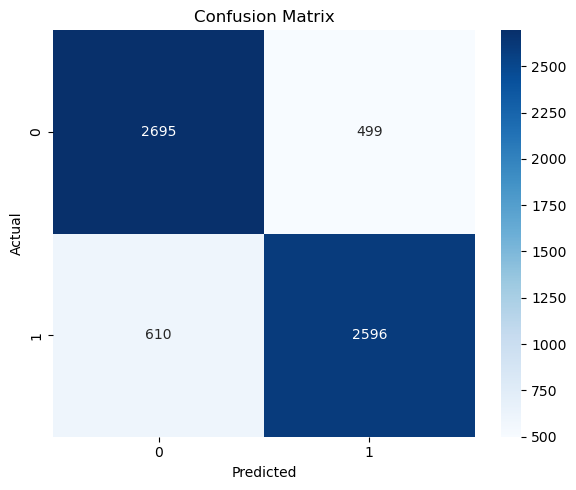


--- Evaluation Metrics for shadow model 2/5 ---
Classifier Accuracy: 0.82828125
Classifier F1 Score: 0.8305319969159599
Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.82      0.83      3194
         1.0       0.82      0.84      0.83      3206

    accuracy                           0.83      6400
   macro avg       0.83      0.83      0.83      6400
weighted avg       0.83      0.83      0.83      6400



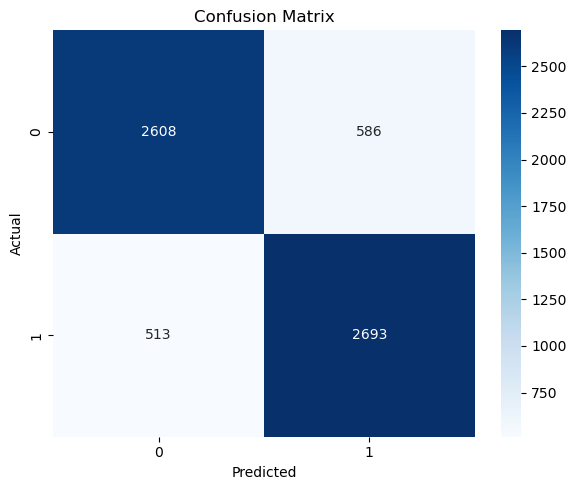


--- Evaluation Metrics for shadow model 3/5 ---
Classifier Accuracy: 0.83390625
Classifier F1 Score: 0.8374866228405443
Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.81      0.83      3194
         1.0       0.82      0.85      0.84      3206

    accuracy                           0.83      6400
   macro avg       0.83      0.83      0.83      6400
weighted avg       0.83      0.83      0.83      6400



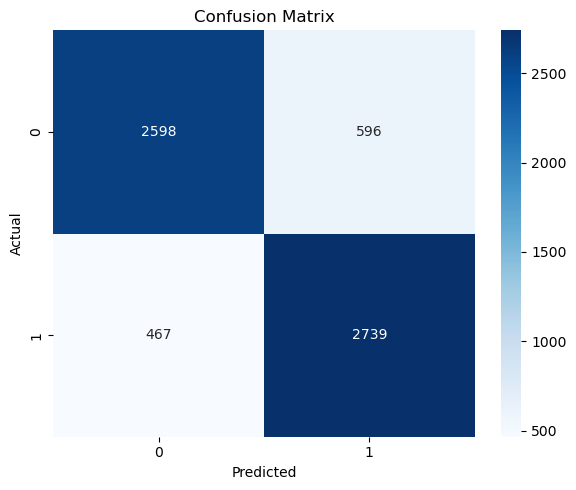


--- Evaluation Metrics for shadow model 4/5 ---
Classifier Accuracy: 0.82640625
Classifier F1 Score: 0.8320483749055178
Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.79      0.82      3194
         1.0       0.81      0.86      0.83      3206

    accuracy                           0.83      6400
   macro avg       0.83      0.83      0.83      6400
weighted avg       0.83      0.83      0.83      6400



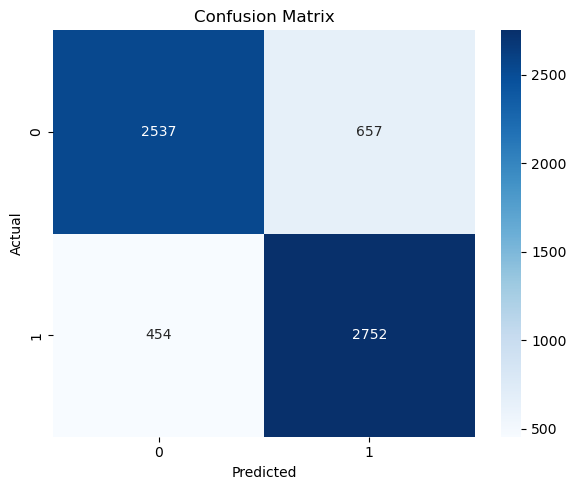


--- Evaluation Metrics for shadow model 5/5 ---
Classifier Accuracy: 0.7971875
Classifier F1 Score: 0.8005531653349723
Classification Report:
               precision    recall  f1-score   support

         0.0       0.81      0.78      0.79      3194
         1.0       0.79      0.81      0.80      3206

    accuracy                           0.80      6400
   macro avg       0.80      0.80      0.80      6400
weighted avg       0.80      0.80      0.80      6400



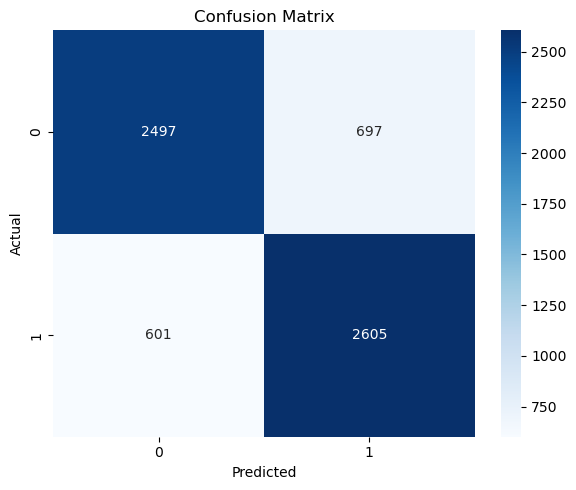

In [13]:
# ====================================
# Step 5: Evaluation and Visualization
# ====================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

''' Done in previous step
y_pred_prob = clf_model.predict(diff_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
'''
for i in range(k):
    print(f"\n--- Evaluation Metrics for shadow model {i+1}/{k} ---")
    print("Classifier Accuracy:", acc[i])
    print("Classifier F1 Score:", f1[i])
    print("Classification Report:\n", classification_report(y_test[i], y_pred[i]))

    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test[i], y_pred[i]), annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"confusionMatrixs/confusion_matrix_shadow{i}.png")
    plt.show()
    # clf_model.save(f"classifiers/snn_classifier_model{i}.h5") Save snn classifier for each shadow model

In [15]:
for i in range(k):
    print(f"\n--- Training data distribution for shadow model {i+1}/{k} ---")
    print("Train label distribution:")
    print(pd.Series(y_train[i]).value_counts())


--- Training data distribution for shadow model 1/5 ---
Train label distribution:
1.0    12825
0.0    12775
Name: count, dtype: int64

--- Training data distribution for shadow model 2/5 ---
Train label distribution:
1.0    12825
0.0    12775
Name: count, dtype: int64

--- Training data distribution for shadow model 3/5 ---
Train label distribution:
1.0    12825
0.0    12775
Name: count, dtype: int64

--- Training data distribution for shadow model 4/5 ---
Train label distribution:
1.0    12825
0.0    12775
Name: count, dtype: int64

--- Training data distribution for shadow model 5/5 ---
Train label distribution:
1.0    12825
0.0    12775
Name: count, dtype: int64


In [17]:
# =========================================
# Learn threshold using raw BERT embeddings
# =========================================

from tensorflow.keras.layers import Dropout
from sklearn.metrics import precision_recall_fscore_support

for i in range(k):
    print(f"\n--- Training MLP Classifier on Raw BERT Embeddings for shadow model {i+1}/{k} ---")
    # -------------------------------------------------------
    # Step 1: Compute absolute differences from raw BERT embeddings
    # -------------------------------------------------------

    X_train_full = np.abs(x1_train[i] - x2_train[i])
    X_test = np.abs(x1_test[i] - x2_test[i])

    # -------------------------------------------------------
    # Step 2: Create pseudo-validation split
    # -------------------------------------------------------

    X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_full, y_train[i], test_size=0.2, random_state=42, stratify=y_train[i]
    )

    # -------------------------------------------------------
    # Step 3: Build and Train MLP Classifier
    # -------------------------------------------------------

    input_dim = X_train_final.shape[1]
    input_layer = Input(shape=(input_dim,))
    x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(input_layer)
    x = Dropout(0.5)(x)
    x = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    output = Dense(1, activation='sigmoid')(x)

    clf_model = Model(inputs=input_layer, outputs=output)
    clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    clf_model.fit(X_train_final, y_train_final, epochs=30, batch_size=256, validation_split=0.1)
    clf_model.save(f"classifiers/mlp_raw_diff_classifier{i}.h5")

    # -------------------------------------------------------
    # Step 4: Tune threshold on validation set
    # -------------------------------------------------------

    y_val_prob = clf_model.predict(X_val).flatten()

    best_threshold = 0.5
    best_f1 = 0

    for threshold in np.arange(0.1, 0.9, 0.01):
        y_pred_val = (y_val_prob >= threshold).astype(int)
        _, _, f1[i], _ = precision_recall_fscore_support(y_val, y_pred_val, average='binary')
        if f1[i] > best_f1:
            best_f1 = f1[i]
            best_threshold = threshold

    print(f"\nBest Threshold (on pseudo-val set): {best_threshold:.2f} — Best F1 Score: {best_f1:.4f}")

    # -------------------------------------------------------
    # Step 5: Evaluate on true test set using tuned threshold
    # -------------------------------------------------------

    y_test_prob = clf_model.predict(X_test).flatten()
    y_test_pred = (y_test_prob >= best_threshold).astype(int)

    acc[i] = accuracy_score(y_test[i], y_test_pred)
    f1[i] = f1_score(y_test[i], y_test_pred)

    print("\nFinal Evaluation on Test Set:")
    print(f"Accuracy: {acc[i]:.4f}")
    print(f"F1 Score: {f1[i]:.4f}")
    print("\nDetailed Report:\n", classification_report(y_test[i], y_test_pred))

    # Save predictions
    pd.DataFrame({
    "True Label": y_test[i],
    "Predicted Label": y_test_pred,
    "Confidence": y_test_prob
    }).to_csv(f"testPredictions/final_test_predictions_raw_mlp_shadow{i}.csv", index=False)
    print("Test predictions saved")

    # Evaluate / predict on TRAIN set (mirror of the test block)
    y_train_prob = clf_model.predict(X_train_full).flatten()
    y_train_pred = (y_train_prob >= best_threshold).astype(int)

    # store metrics (keeps using same acc/f1 arrays indexed by i)
    acc[i] = accuracy_score(y_train[i], y_train_pred)
    f1[i] = f1_score(y_train[i], y_train_pred)

    print("\nFinal Evaluation on Train Set:")
    print(f"Accuracy: {acc[i]:.4f}")
    print(f"F1 Score: {f1[i]:.4f}")
    print("\nDetailed Report:\n", classification_report(y_train[i], y_train_pred))

    # Save train predictions
    pd.DataFrame({
        "True Label": y_train[i],
        "Predicted Label": y_train_pred,
        "Confidence": y_train_prob
    }).to_csv(f"trainPredictions/final_train_predictions_raw_mlp_shadow{i}.csv", index=False)
    print("Train predictions saved")


--- Training MLP Classifier on Raw BERT Embeddings for shadow model 1/5 ---
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6993 - loss: 1.3774 - val_accuracy: 0.8252 - val_loss: 0.8089
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8408 - loss: 0.6729 - val_accuracy: 0.8770 - val_loss: 0.5322
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8561 - loss: 0.5185 - val_accuracy: 0.8936 - val_loss: 0.4368
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8703 - loss: 0.4475 - val_accuracy: 0.8979 - val_loss: 0.3950
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8784 - loss: 0.4063 - val_accuracy: 0.8970 - val_loss: 0.3687
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8809 - loss: 0.3872 - val_accuracy: 0.9004 - val_loss: 0.3477
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8836 - loss: 0.3784 - val_accuracy: 0.8921 - val_loss: 0.3570
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 

160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step

Best Threshold (on pseudo-val set): 0.43 — Best F1 Score: 0.9037
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step

Final Evaluation on Test Set:
Accuracy: 0.8997
F1 Score: 0.9006

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.91      0.89      0.90      3194
         1.0       0.89      0.91      0.90      3206

    accuracy                           0.90      6400
   macro avg       0.90      0.90      0.90      6400
weighted avg       0.90      0.90      0.90      6400

Test predictions saved
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step

Final Evaluation on Train Set:
Accuracy: 0.9066
F1 Score: 0.9073

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.91      0.90      0.91     12775
         1.0       0.90      0.91      0.91     12825

    accuracy                           0.91     25600
   macro avg       0.91      0.91      0.91     25600
weighted avg  

160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step

Best Threshold (on pseudo-val set): 0.50 — Best F1 Score: 0.9037
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step

Final Evaluation on Test Set:
Accuracy: 0.8911
F1 Score: 0.8953

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.92      0.85      0.89      3194
         1.0       0.86      0.93      0.90      3206

    accuracy                           0.89      6400
   macro avg       0.89      0.89      0.89      6400
weighted avg       0.89      0.89      0.89      6400

Test predictions saved
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step

Final Evaluation on Train Set:
Accuracy: 0.9057
F1 Score: 0.9090

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.93      0.87      0.90     12775
         1.0       0.88      0.94      0.91     12825

    accuracy                           0.91     25600
   macro avg       0.91      0.91      0.91     25600
weighted avg  

160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step

Best Threshold (on pseudo-val set): 0.66 — Best F1 Score: 0.9119
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step

Final Evaluation on Test Set:
Accuracy: 0.8969
F1 Score: 0.8966

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.89      0.90      0.90      3194
         1.0       0.90      0.89      0.90      3206

    accuracy                           0.90      6400
   macro avg       0.90      0.90      0.90      6400
weighted avg       0.90      0.90      0.90      6400

Test predictions saved
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step

Final Evaluation on Train Set:
Accuracy: 0.9068
F1 Score: 0.9064

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.90      0.91      0.91     12775
         1.0       0.91      0.90      0.91     12825

    accuracy                           0.91     25600
   macro avg       0.91      0.91      0.91     25600
weighted avg  

160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step

Best Threshold (on pseudo-val set): 0.51 — Best F1 Score: 0.9053
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step

Final Evaluation on Test Set:
Accuracy: 0.8977
F1 Score: 0.8991

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.91      0.88      0.90      3194
         1.0       0.89      0.91      0.90      3206

    accuracy                           0.90      6400
   macro avg       0.90      0.90      0.90      6400
weighted avg       0.90      0.90      0.90      6400

Test predictions saved
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step

Final Evaluation on Train Set:
Accuracy: 0.9092
F1 Score: 0.9106

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.92      0.90      0.91     12775
         1.0       0.90      0.92      0.91     12825

    accuracy                           0.91     25600
   macro avg       0.91      0.91      0.91     25600
weighted avg  

160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step

Best Threshold (on pseudo-val set): 0.42 — Best F1 Score: 0.9031
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step

Final Evaluation on Test Set:
Accuracy: 0.8995
F1 Score: 0.9029

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.93      0.87      0.90      3194
         1.0       0.88      0.93      0.90      3206

    accuracy                           0.90      6400
   macro avg       0.90      0.90      0.90      6400
weighted avg       0.90      0.90      0.90      6400

Test predictions saved
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step

Final Evaluation on Train Set:
Accuracy: 0.9046
F1 Score: 0.9082

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.94      0.87      0.90     12775
         1.0       0.88      0.94      0.91     12825

    accuracy                           0.90     25600
   macro avg       0.91      0.90      0.90     25600
weighted avg  

Scanning for MLP models under: ./classifiers
  Found MLP models: ['0', '1', '2', '3', '4']
Available shadow IDs (with both train+test): ['0', '1', '2', '3', '4']

Running experiments for k = 1 (using first 1 shadow(s))
  chosen sids: ['0']

--- repeat 1/1 for k=1 ---
Built attack dataset X=(32000, 4), y=(32000,), pos_frac=0.800 (using 1 shadow(s))
  training attack model -> ./attack_model_k1_r0.h5 (use_sklearn=False)
Epoch 1/30
75/75 - 1s - 12ms/step - accuracy: 0.7976 - loss: 0.5386 - val_accuracy: 0.8000 - val_loss: 0.5023
Epoch 2/30
75/75 - 0s - 2ms/step - accuracy: 0.8000 - loss: 0.5011 - val_accuracy: 0.8000 - val_loss: 0.5011
Epoch 3/30
75/75 - 0s - 2ms/step - accuracy: 0.8000 - loss: 0.5007 - val_accuracy: 0.8000 - val_loss: 0.5014
Epoch 4/30
75/75 - 0s - 2ms/step - accuracy: 0.8000 - loss: 0.5009 - val_accuracy: 0.8000 - val_loss: 0.5010
Epoch 5/30
75/75 - 0s - 2ms/step - accuracy: 0.8000 - loss: 0.5008 - val_accuracy: 0.8000 - val_loss: 0.5008
Epoch 6/30
75/75 - 0s - 2ms/step 

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step
Attack eval -- AUC: 0.5044, Acc: 0.8000, Prec: 0.8000, Rec: 1.0000, F1: 0.8889

Summary for k=1 over 1 repeats -> AUC: 0.5044 ± 0.0000, ACC: 0.8000 ± 0.0000

Running experiments for k = 2 (using first 2 shadow(s))
  chosen sids: ['0', '1']

--- repeat 1/1 for k=2 ---
Built attack dataset X=(64000, 4), y=(64000,), pos_frac=0.800 (using 2 shadow(s))
  training attack model -> ./attack_model_k2_r0.h5 (use_sklearn=False)
Epoch 1/30
150/150 - 1s - 6ms/step - accuracy: 0.7930 - loss: 0.5265 - val_accuracy: 0.8000 - val_loss: 0.5007
Epoch 2/30
150/150 - 0s - 1ms/step - accuracy: 0.8000 - loss: 0.5006 - val_accuracy: 0.8000 - val_loss: 0.5005
Epoch 3/30
150/150 - 0s - 1ms/step - accuracy: 0.8000 - loss: 0.5005 - val_accuracy: 0.8000 - val_loss: 0.5005
Epoch 4/30
150/150 - 0s - 1ms/step - accuracy: 0.8000 - loss: 0.5005 - val_accuracy: 0.8000 - val_loss: 0.5004
Epoch 5/30
150/150 - 0s - 1ms/step - accuracy: 0.8000 - loss: 0.5007 - val_accuracy: 0.8000 

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step
Attack eval -- AUC: 0.5034, Acc: 0.8000, Prec: 0.8000, Rec: 1.0000, F1: 0.8889

Summary for k=2 over 1 repeats -> AUC: 0.5034 ± 0.0000, ACC: 0.8000 ± 0.0000

Running experiments for k = 3 (using first 3 shadow(s))
  chosen sids: ['0', '1', '2']

--- repeat 1/1 for k=3 ---
Built attack dataset X=(96000, 4), y=(96000,), pos_frac=0.800 (using 3 shadow(s))
  training attack model -> ./attack_model_k3_r0.h5 (use_sklearn=False)
Epoch 1/30
225/225 - 1s - 4ms/step - accuracy: 0.7980 - loss: 0.5096 - val_accuracy: 0.8000 - val_loss: 0.5014
Epoch 2/30
225/225 - 0s - 1ms/step - accuracy: 0.8000 - loss: 0.5005 - val_accuracy: 0.8000 - val_loss: 0.5008
Epoch 3/30
225/225 - 0s - 1ms/step - accuracy: 0.8000 - loss: 0.5006 - val_accuracy: 0.8000 - val_loss: 0.5011
Epoch 4/30
225/225 - 0s - 1ms/step - accuracy: 0.8000 - loss: 0.5009 - val_accuracy: 0.8000 - val_loss: 0.5006
Epoch 5/30
225/225 - 0s - 1ms/step - accuracy: 0.8000 - loss: 0.5005 - val_accuracy: 0.

750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step
Attack eval -- AUC: 0.5089, Acc: 0.8000, Prec: 0.8000, Rec: 1.0000, F1: 0.8889

Summary for k=3 over 1 repeats -> AUC: 0.5089 ± 0.0000, ACC: 0.8000 ± 0.0000

Running experiments for k = 4 (using first 4 shadow(s))
  chosen sids: ['0', '1', '2', '3']

--- repeat 1/1 for k=4 ---
Built attack dataset X=(128000, 4), y=(128000,), pos_frac=0.800 (using 4 shadow(s))
  training attack model -> ./attack_model_k4_r0.h5 (use_sklearn=False)
Epoch 1/30
300/300 - 1s - 3ms/step - accuracy: 0.7945 - loss: 0.5123 - val_accuracy: 0.8000 - val_loss: 0.5004
Epoch 2/30
300/300 - 0s - 1ms/step - accuracy: 0.8000 - loss: 0.5006 - val_accuracy: 0.8000 - val_loss: 0.5005
Epoch 3/30
300/300 - 0s - 1ms/step - accuracy: 0.8000 - loss: 0.5007 - val_accuracy: 0.8000 - val_loss: 0.5003
Epoch 4/30
300/300 - 0s - 1ms/step - accuracy: 0.8000 - loss: 0.5006 - val_accuracy: 0.8000 - val_loss: 0.5008
Epoch 5/30
300/300 - 0s - 1ms/step - accuracy: 0.8000 - loss: 0.5005 - val_accur

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 417us/step
Attack eval -- AUC: 0.4958, Acc: 0.8000, Prec: 0.8000, Rec: 1.0000, F1: 0.8889

Summary for k=4 over 1 repeats -> AUC: 0.4958 ± 0.0000, ACC: 0.8000 ± 0.0000

Running experiments for k = 5 (using first 5 shadow(s))
  chosen sids: ['0', '1', '2', '3', '4']

--- repeat 1/1 for k=5 ---
Built attack dataset X=(160000, 4), y=(160000,), pos_frac=0.800 (using 5 shadow(s))
  training attack model -> ./attack_model_k5_r0.h5 (use_sklearn=False)
Epoch 1/30
375/375 - 1s - 3ms/step - accuracy: 0.7967 - loss: 0.5078 - val_accuracy: 0.8000 - val_loss: 0.5005
Epoch 2/30
375/375 - 0s - 977us/step - accuracy: 0.8000 - loss: 0.5006 - val_accuracy: 0.8000 - val_loss: 0.5004
Epoch 3/30
375/375 - 0s - 971us/step - accuracy: 0.8000 - loss: 0.5006 - val_accuracy: 0.8000 - val_loss: 0.5005
Epoch 4/30
375/375 - 0s - 973us/step - accuracy: 0.8000 - loss: 0.5005 - val_accuracy: 0.8000 - val_loss: 0.5005
Epoch 5/30
375/375 - 0s - 974us/step - accuracy: 0.8000 - loss: 0.5

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 404us/step
Attack eval -- AUC: 0.5065, Acc: 0.8000, Prec: 0.8000, Rec: 1.0000, F1: 0.8889

Summary for k=5 over 1 repeats -> AUC: 0.5065 ± 0.0000, ACC: 0.8000 ± 0.0000


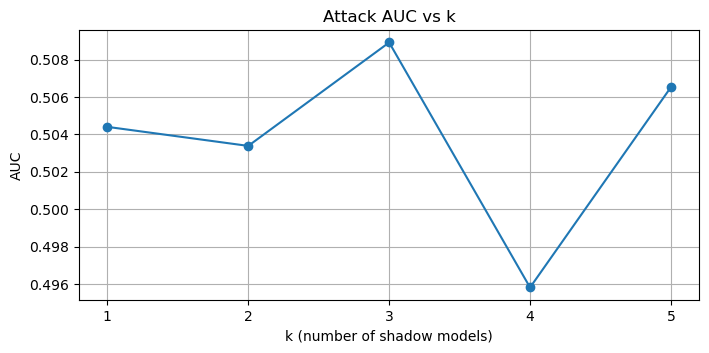

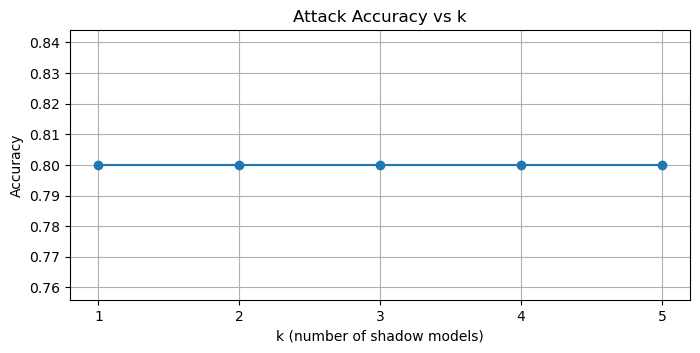

In [27]:
#!/usr/bin/env python3
"""
Attack pipeline that builds attack dataset from CSVs using:
  - confidence
  - true label (mapped to int per-file)
  - predicted label (mapped to int per-file)
  - correct flag (pred == true)

Extended to support k-sweep experiments:
  --ks  : comma-separated list of k values (e.g. "1,3,5,10")
  --repeats : how many repeats per k (default 1)
  --consistent-eval : build a single held-out eval set from ALL shadows and use the same eval set for every k
  --per-shadow-limit : limit how many rows to take from each shadow's train/test CSVs (for balancing / speed)
  --results-csv : file to save aggregated results

Usage:
  python attack_pipeline_confidence_features.py --shadow-dir . --out-model ./attack_model.h5 --ks 1,3,5
  add --use-sklearn to use RandomForest and save via joblib
  add --balance to balance classes
"""

import os
import re
import argparse
from glob import glob
import math
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support

# TensorFlow / Keras imports (optional if using sklearn)
try:
    from tensorflow import keras
    from tensorflow.keras import layers
except Exception:
    keras = None
    layers = None

# --------------------------
# Discover MLP model files (unchanged behavior)
# --------------------------
def discover_mlp_models(shadow_dir):
    shadows = {}
    search_dirs = [shadow_dir, os.path.join(shadow_dir, 'classifiers')]
    for sdir in search_dirs:
        if not os.path.exists(sdir):
            continue
        for p in glob(os.path.join(sdir, '**', '*.h5'), recursive=True) + glob(os.path.join(sdir, '**', '*.keras'), recursive=True):
            name = os.path.basename(p)
            m = re.search(r'mlp_raw_diff_classifier[_-]?(\d+)', name, re.IGNORECASE)
            if m:
                sid = m.group(1)
                shadows[sid] = p
                continue
            if 'mlp' in name.lower():
                sid = name
                shadows[sid] = p
    return shadows

# --------------------------
# Find test CSVs (unchanged behavior)
# --------------------------
def find_test_csvs(shadow_dir):
    csv_dir = os.path.join(shadow_dir, 'testPredictions')
    results = {}
    if not os.path.exists(csv_dir):
        return results
    for p in glob(os.path.join(csv_dir, '*.csv')) + glob(os.path.join(csv_dir, '**', '*.csv'), recursive=True):
        name = os.path.basename(p)
        m = re.search(r'final[_-]?test[_-]?predictions[_-]?raw[_-]?mlp[_-]?shadow[_-]?(\d+)', name, re.IGNORECASE)
        if m:
            sid = m.group(1)
            results[sid] = p
            continue
        m2 = re.search(r'test.*?shadow[_-]?(\d+)', name, re.IGNORECASE)
        if m2:
            sid = m2.group(1)
            results[sid] = p
    return results

# --------------------------
# Train CSV path (unchanged behavior)
# --------------------------
def train_csv_path_for_sid(shadow_dir, sid):
    csv_dir = os.path.join(shadow_dir, 'trainPredictions')
    return os.path.join(csv_dir, f"final_train_predictions_raw_mlp_shadow{sid}.csv")

# --------------------------
# Extract multi-features from CSV (unchanged logic)
# --------------------------
def extract_features_from_csv(path):
    """
    Returns features array shape (n_rows, 4):
      [confidence, true_label_int, predicted_label_int, correct_flag]
    Fallback behavior:
      - missing confidence -> first numeric column or zeros
      - missing labels -> -1
      - non-numeric labels mapped to integers per-file
    """
    df = pd.read_csv(path)
    cols = [c.lower().strip() for c in df.columns]

    # 1) Confidence detection
    conf_idx = None
    for i, c in enumerate(cols):
        if c in ('confidence', 'conf') or 'prob' in c or 'probability' in c:
            conf_idx = i
            break
    if conf_idx is not None:
        try:
            conf = df.iloc[:, conf_idx].astype(float).values.reshape(-1, 1)
        except Exception:
            # fallback to numeric coercion then zeros
            try:
                conf = pd.to_numeric(df.iloc[:, conf_idx], errors='coerce').fillna(0.0).values.reshape(-1,1)
            except Exception:
                conf = np.zeros((len(df), 1), dtype=float)
    else:
        # fallback to first numeric column
        df_num = df.select_dtypes(include=[np.number])
        if df_num.shape[1] > 0:
            conf = df_num.iloc[:, 0].astype(float).values.reshape(-1, 1)
        else:
            conf = np.zeros((len(df), 1), dtype=float)

    # 2) True label detection
    true_idx = None
    for i, c in enumerate(cols):
        if c in ('true_label', 'label', 'y_true', 'target', 'ground_truth'):
            true_idx = i
            break
    if true_idx is None:
        for i, c in enumerate(cols):
            if 'true' in c and 'pred' not in c:
                true_idx = i
                break
    if true_idx is not None:
        true_vals = df.iloc[:, true_idx].values
    else:
        true_vals = np.array([-1] * len(df))

    # 3) Predicted label detection
    pred_idx = None
    for i, c in enumerate(cols):
        if c in ('predicted', 'pred', 'y_pred', 'prediction', 'pred_label'):
            pred_idx = i
            break
    if pred_idx is None:
        for i, c in enumerate(cols):
            if 'pred' in c or 'prediction' in c:
                pred_idx = i
                break
    if pred_idx is not None:
        pred_vals = df.iloc[:, pred_idx].values
    else:
        pred_vals = np.array([-1] * len(df))

    # 4) Map non-numeric labels to integers (per-file)
    tv = np.asarray(true_vals, dtype=object)
    pv = np.asarray(pred_vals, dtype=object)

    # Collect unique non-placeholder values
    union_candidates = []
    for v in np.unique(np.concatenate([tv, pv]).astype(object)):
        if v == -1 or (isinstance(v, (int, np.integer)) and int(v) == -1):
            continue
        union_candidates.append(v)

    # Build mapping stable by string sort
    mapping = {}
    for i, v in enumerate(sorted(union_candidates, key=lambda x: str(x))):
        mapping[v] = i

    def map_val(v):
        if isinstance(v, (int, np.integer)) and int(v) != -1:
            return int(v)
        if isinstance(v, (float, np.floating)) and not np.isnan(v):
            try:
                return int(v)
            except Exception:
                pass
        if v == -1:
            return -1
        return mapping.get(v, -1)

    true_mapped = np.array([map_val(v) for v in tv], dtype=int).reshape(-1, 1)
    pred_mapped = np.array([map_val(v) for v in pv], dtype=int).reshape(-1, 1)

    # 5) Correct flag
    correct = (true_mapped.reshape(-1) != -1) & (true_mapped.reshape(-1) == pred_mapped.reshape(-1))
    correct = correct.astype(int).reshape(-1, 1)

    # 6) Stack into features
    features = np.hstack([conf, true_mapped.astype(float), pred_mapped.astype(float), correct.astype(float)])
    return features

# --------------------------
# Build attack dataset from CSVs (extended to accept subset and per-shadow limit)
# --------------------------
def build_attack_dataset_from_csvs_features(shadow_dir,
                                           test_csv_map,
                                           sids_subset=None,
                                           per_shadow_sample_limit=None,
                                           force_require_train=True):
    """
    Builds attack dataset from pairs of train/test CSVs.

    - test_csv_map: dict sid -> test_csv_path (as produced by find_test_csvs)
    - sids_subset: optional iterable of sid strings to restrict which shadows to include (keeps original ordering)
    - per_shadow_sample_limit: optional int to limit rows per train/test file (sample without replacement)
    - force_require_train: if True, error when no pairs found; otherwise return (None,None)

    Returns (X_attack, y_attack)
    """
    X_parts = []
    y_parts = []

    # determine which sids to process, but preserve ordering
    available_sids = list(test_csv_map.keys())
    if sids_subset is not None:
        sids_to_run = [sid for sid in available_sids if sid in set(sids_subset)]
    else:
        sids_to_run = available_sids

    for sid in sids_to_run:
        test_path = test_csv_map.get(sid)
        train_path = train_csv_path_for_sid(shadow_dir, sid)
        if not test_path or not os.path.exists(test_path):
            print(f"  Shadow {sid}: missing test CSV at {test_path} -> skipping")
            continue
        if not os.path.exists(train_path):
            print(f"  Shadow {sid}: missing train CSV at {train_path} -> skipping")
            continue

        try:
            pm = extract_features_from_csv(train_path)
            pn = extract_features_from_csv(test_path)
        except Exception as e:
            print(f"  Shadow {sid}: error loading CSVs: {e} -> skipping")
            continue

        # optional sampling per shadow
        if per_shadow_sample_limit is not None:
            def sample_rows(arr, n_limit):
                n = arr.shape[0]
                if n <= n_limit:
                    return arr
                idx = np.random.choice(n, n_limit, replace=False)
                return arr[idx]
            pm = sample_rows(pm, per_shadow_sample_limit)
            pn = sample_rows(pn, per_shadow_sample_limit)

        # Defensive: pad arrays if feature dim mismatch (shouldn't normally happen)
        if pm.shape[1] != pn.shape[1]:
            max_cols = max(pm.shape[1], pn.shape[1])
            def pad(arr, ncols):
                if arr.shape[1] < ncols:
                    pad_width = ncols - arr.shape[1]
                    pad_arr = np.full((arr.shape[0], pad_width), -1.0)
                    return np.hstack([arr, pad_arr])
                return arr
            pm = pad(pm, max_cols)
            pn = pad(pn, max_cols)

        X_parts.append(pm)
        y_parts.append(np.ones(pm.shape[0], dtype=int))
        X_parts.append(pn)
        y_parts.append(np.zeros(pn.shape[0], dtype=int))

    if not X_parts:
        if force_require_train:
            raise RuntimeError("No shadow CSV pairs (train+test) found to build attack dataset.")
        else:
            return None, None

    X_attack = np.vstack(X_parts)
    y_attack = np.concatenate(y_parts)
    print(f"Built attack dataset X={X_attack.shape}, y={y_attack.shape}, pos_frac={y_attack.mean():.3f} (using {len(X_parts)//2} shadow(s))")
    return X_attack, y_attack

# --------------------------
# Build simple MLP attack model
# --------------------------
def build_attack_model(input_dim, hidden_sizes=(64, 32), lr=1e-3):
    if keras is None:
        raise RuntimeError("Keras is not available. Install TensorFlow to use the MLP attack model.")
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for h in hidden_sizes:
        model.add(layers.Dense(h, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --------------------------
# Train attack model (Keras or sklearn)
# --------------------------
def train_attack_model(X, y, use_sklearn=False, out_path='attack_model.h5', epochs=30, verbose=2):
    if use_sklearn:
        clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        clf.fit(X, y)
        # ensure joblib .joblib extension if user passed .h5 accidentally
        out = out_path if out_path.endswith('.joblib') or out_path.endswith('.pkl') else (out_path + '.joblib' if not out_path.endswith('.joblib') else out_path)
        joblib.dump(clf, out)
        return clf, out
    else:
        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        model = build_attack_model(X.shape[1])
        model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=epochs, batch_size=256, verbose=verbose)
        # save
        out = out_path
        model.save(out)
        return model, out

# --------------------------
# Evaluate attack and print metrics line like original pipeline
# --------------------------
def evaluate_attack(model, X, y, sklearn_flag=False):
    if sklearn_flag:
        # sklearn classifier (RandomForest)
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X)[:, 1]
        else:
            if hasattr(model, 'decision_function'):
                scores = model.decision_function(X)
                mn, mx = float(scores.min()), float(scores.max())
                probs = (scores - mn) / (mx - mn + 1e-12)
            else:
                probs = model.predict(X).astype(float)
        preds = (probs > 0.5).astype(int)
    else:
        probs = model.predict(X).reshape(-1)
        preds = (probs > 0.5).astype(int)

    if len(np.unique(y)) != 2:
        raise ValueError("Only one class present in y; evaluation metrics require both classes.")

    auc = roc_auc_score(y, probs)
    acc = accuracy_score(y, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y, preds, average='binary')
    print(f"Attack eval -- AUC: {auc:.4f}, Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
    return {'auc': auc, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1}

# --------------------------
# Top-level orchestration for ks sweep
# --------------------------
def run_pipeline_confidence_k_sweep(args):
    shadow_dir = args.shadow_dir
    out_model_base = args.out_model
    use_sklearn = args.use_sklearn
    epochs = args.epochs
    balance_flag = args.balance
    ks = args.ks
    repeats = args.repeats
    per_shadow_limit = args.per_shadow_limit
    results_csv = args.results_csv
    consistent_eval = args.consistent_eval
    eval_frac = args.eval_frac

    print(f"Scanning for MLP models under: {shadow_dir}/classifiers")
    mlp_models = discover_mlp_models(shadow_dir)
    print(f"  Found MLP models: {list(mlp_models.keys())}")

    test_csvs = find_test_csvs(shadow_dir)
    if not test_csvs:
        raise RuntimeError(f"No test CSVs found under {os.path.join(shadow_dir,'testPredictions')}.")

    # Filter to only sids that have both train and test CSVs
    available_sids = []
    for sid, test_path in sorted(test_csvs.items(), key=lambda x: str(x[0])):
        train_path = train_csv_path_for_sid(shadow_dir, sid)
        if os.path.exists(train_path) and os.path.exists(test_path):
            available_sids.append(sid)
        else:
            print(f"Skipping sid {sid}: missing train or test CSV.")

    if not available_sids:
        raise RuntimeError("No shadow ID pairs (train+test) available to run experiments.")

    print(f"Available shadow IDs (with both train+test): {available_sids}")

    # Optionally build a consistent evaluation set from ALL available shadows
    X_eval_consistent = None
    y_eval_consistent = None
    if consistent_eval:
        print("Building consistent evaluation set from union of ALL available shadows.")
        X_full, y_full = build_attack_dataset_from_csvs_features(shadow_dir, test_csvs, sids_subset=available_sids, per_shadow_sample_limit=per_shadow_limit, force_require_train=True)
        # stratified split to create a holdout evaluation set
        _, X_eval_consistent, _, y_eval_consistent = train_test_split(X_full, y_full, test_size=eval_frac, random_state=42, stratify=y_full)
        print(f"Consistent eval set size: {len(X_eval_consistent)} (pos_frac={y_eval_consistent.mean():.3f})")

    # Prepare to collect results
    rows = []

    # For reproducibility between repeats, we will use a deterministic order of sids for k selection
    # i.e. first k of available_sids (sorted)
    for k in ks:
        print("\n" + "="*60)
        print(f"Running experiments for k = {k} (using first {k} shadow(s))")
        chosen_sids = available_sids[:k]
        print(f"  chosen sids: {chosen_sids}")

        repeat_metrics = []
        for rep in range(repeats):
            print(f"\n--- repeat {rep+1}/{repeats} for k={k} ---")
            # Build attack dataset limited to chosen_sids
            X_attack, y_attack = build_attack_dataset_from_csvs_features(shadow_dir, test_csvs, sids_subset=chosen_sids, per_shadow_sample_limit=per_shadow_limit, force_require_train=True)

            # Optional balancing before training
            if balance_flag:
                from sklearn.utils import resample
                pos = X_attack[y_attack == 1]
                neg = X_attack[y_attack == 0]
                n = min(len(pos), len(neg))
                pos_s = resample(pos, n_samples=n, random_state=42 + rep)
                neg_s = resample(neg, n_samples=n, random_state=42 + rep)
                X_attack = np.vstack([pos_s, neg_s])
                y_attack = np.concatenate([np.ones(n), np.zeros(n)])
                print(f"  Balanced attack dataset to {X_attack.shape}")

            # determine eval set
            if consistent_eval:
                X_eval = X_eval_consistent
                y_eval = y_eval_consistent
            else:
                # split from current attack dataset (stratified)
                X_train_atk, X_eval, y_train_atk, y_eval = train_test_split(X_attack, y_attack, test_size=0.25, random_state=42 + rep, stratify=y_attack)

            # train attack model on training portion
            if consistent_eval:
                # if consistent eval, train on entire X_attack (no further split) or do a split for validation - we will fit on X_attack
                train_X = X_attack
                train_y = y_attack
            else:
                train_X = X_train_atk
                train_y = y_train_atk

            # train and save model with k and rep suffix
            suffix = f"_k{k}_r{rep}"
            out_path = out_model_base
            base, ext = os.path.splitext(out_path)
            if use_sklearn:
                out_model_path = f"{base}{suffix}.joblib"
            else:
                # keep ext if .h5 or .keras otherwise add suffix + .h5
                if ext.lower() in ['.h5', '.keras']:
                    out_model_path = f"{base}{suffix}{ext}"
                else:
                    out_model_path = f"{base}{suffix}.h5"

            print(f"  training attack model -> {out_model_path} (use_sklearn={use_sklearn})")
            model, saved_path = train_attack_model(train_X, train_y, use_sklearn=use_sklearn, out_path=out_model_path, epochs=epochs, verbose=2)

            # Evaluate on chosen evaluation set (consistent or split)
            eval_metrics = evaluate_attack(model, X_eval, y_eval, sklearn_flag=use_sklearn)

            row = {
                'k': k,
                'repeat': rep,
                'n_shadows_used': len(chosen_sids),
                'n_attack_train': len(train_X),
                'n_attack_eval': len(X_eval),
                'model_path': saved_path,
                'auc': eval_metrics['auc'],
                'acc': eval_metrics['acc'],
                'prec': eval_metrics['prec'],
                'rec': eval_metrics['rec'],
                'f1': eval_metrics['f1']
            }
            rows.append(row)
            repeat_metrics.append(eval_metrics)

        # summarize repeats for this k
        def mean_of_metric(key):
            vals = [m[key] for m in repeat_metrics]
            return float(np.mean(vals)), float(np.std(vals))

        auc_mean, auc_std = mean_of_metric('auc')
        acc_mean, acc_std = mean_of_metric('acc')
        print(f"\nSummary for k={k} over {repeats} repeats -> AUC: {auc_mean:.4f} ± {auc_std:.4f}, ACC: {acc_mean:.4f} ± {acc_std:.4f}")

    # Save results to CSV if requested
    if results_csv:
        df = pd.DataFrame(rows)
        df.to_csv(results_csv, index=False)
        print(f"\nSaved results to {results_csv}")

    # Produce a simple plot of mean AUC/Acc vs k
    if rows:
        df = pd.DataFrame(rows)
        agg = df.groupby('k').agg({'auc': ['mean', 'std'], 'acc': ['mean', 'std']}).reset_index()
        agg.columns = ['k', 'auc_mean', 'auc_std', 'acc_mean', 'acc_std']
        plt.figure(figsize=(8,3.5))
        plt.errorbar(agg['k'], agg['auc_mean'], yerr=agg['auc_std'], marker='o', label='AUC')
        plt.xlabel('k (number of shadow models)')
        plt.ylabel('AUC')
        plt.title('Attack AUC vs k')
        plt.grid(True)
        plt.xticks(agg['k'])
        plt.show()

        plt.figure(figsize=(8,3.5))
        plt.errorbar(agg['k'], agg['acc_mean'], yerr=agg['acc_std'], marker='o', label='Accuracy')
        plt.xlabel('k (number of shadow models)')
        plt.ylabel('Accuracy')
        plt.title('Attack Accuracy vs k')
        plt.grid(True)
        plt.xticks(agg['k'])
        plt.show()

    return rows

# --------------------------
# Command-line entrypoint
# --------------------------
def parse_ks_arg(s):
    # parse comma-separated ints, allow single ints
    parts = [p.strip() for p in s.split(',') if p.strip()]
    ks = []
    for p in parts:
        try:
            ks.append(int(p))
        except Exception:
            pass
    return sorted(list(set(ks)))

def main():
    p = argparse.ArgumentParser()
    p.add_argument('--shadow-dir', type=str, default='.', help='Project root containing classifiers/, testPredictions/ and trainPredictions/')
    p.add_argument('--out-model', type=str, default='./attack_model.h5', help='Base path for saved attack models; suffixes _k{K}_r{R} will be appended.')
    p.add_argument('--use-sklearn', action='store_true', help='Use sklearn RandomForest and save via joblib')
    p.add_argument('--balance', action='store_true', help='Balance positive/negative classes before training')
    p.add_argument('--epochs', type=int, default=30, help='Epochs for attack MLP training (if using Keras)')
    p.add_argument('--ks', type=str, default='1,2,3,4,5', help='Comma-separated list of k values to test (e.g. "1,3,5,10")')
    p.add_argument('--repeats', type=int, default=1, help='Number of repeats per k (default 1)')
    p.add_argument('--per-shadow-limit', type=int, default=None, help='Limit rows sampled per shadow train/test CSV (int)')
    p.add_argument('--results-csv', type=str, default=None, help='Save aggregated results to CSV')
    p.add_argument('--consistent-eval', action='store_true', help='Build one consistent held-out eval set from all shadows and use it for every k')
    p.add_argument('--eval-frac', type=float, default=0.25, help='Fraction of full dataset to hold out for consistent eval (when --consistent-eval used)')
    p.add_argument('--no-plot', action='store_true', help='Do not show plots (useful for headless runs)')
    args, _unknown = p.parse_known_args()

    args.ks = parse_ks_arg(args.ks)
    rows = run_pipeline_confidence_k_sweep(args)
    if args.no_plot:
        plt.close('all')
    return rows

if __name__ == '__main__':
    main()
